##Step 03 - Pinecone Serverless Index

In [ ]:
pc = Pinecone(api_key=PINECONE_API_KEY)

existing_names = [idx.name for idx in pc.list_indexes()]
if PINECONE_INDEX_NAME not in existing_names:
    print(f"Creating Pinecone index '{PINECONE_INDEX_NAME}'...")
    pc.create_index(
        name=PINECONE_INDEX_NAME,
        dimension=EMBEDDING_DIM,
        metric="cosine",
        spec=ServerlessSpec(cloud=PINECONE_CLOUD, region=PINECONE_REGION),
    )
    # Poll until the index is ready (typically <30 sec)
    while True:
        status = pc.describe_index(PINECONE_INDEX_NAME).status
        if status.get("ready"):
            break
        print("  Waiting for index to be ready...")
        time.sleep(5)
    print("  Index created and ready!")
else:
    print(f"Index '{PINECONE_INDEX_NAME}' already exists -- skipping creation")

pinecone_index = pc.Index(PINECONE_INDEX_NAME)
print("Pinecone index connected")
print("Stats:", pinecone_index.describe_index_stats())


Index 'rag-showdown-384' already exists -- skipping creation
Pinecone index connected
Stats: {'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}


In [ ]:
# Creating New Index for 384 vector size
from pinecone import Pinecone, ServerlessSpec

pc = Pinecone(api_key=PINECONE_API_KEY)

pc.create_index(
    name="rag-showdown-384",
    dimension=384,
    metric="cosine",
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

{
    "name": "rag-showdown-384",
    "metric": "cosine",
    "host": "rag-showdown-384-hbihqh2.svc.aped-4627-b74a.pinecone.io",
    "spec": {
        "serverless": {
            "cloud": "aws",
            "region": "us-east-1"
        }
    },
    "status": {
        "ready": true,
        "state": "Ready"
    },
    "vector_type": "dense",
    "dimension": 384,
    "deletion_protection": "disabled",
    "tags": null
}

In [ ]:
print(PINECONE_INDEX_NAME)

rag-showdown-384


In [ ]:
BATCH = 100
print(f"Upserting {len(all_docs)} vectors to Pinecone...")
t0 = time.perf_counter()

for i in tqdm(range(0, len(all_docs), BATCH), desc="Upserting"):
    batch_end = min(i + BATCH, len(all_docs))
    pinecone_index.upsert(vectors=[
        {
            "id":       f"doc-{i + j}",
            "values":   all_vectors[i + j],
            "metadata": {
                "title": metas[i + j].get("title", ""),
                "url":   metas[i + j].get("url", ""),
                "text":  texts[i + j][:400],
            },
        }
        for j in range(batch_end - i)
    ])

print(f"Upserted {len(all_docs)} vectors in {time.perf_counter()-t0:.1f}s")
print("Final stats:", pinecone_index.describe_index_stats())

Upserting 40 vectors to Pinecone...


Upserting:   0%|          | 0/1 [00:00<?, ?it/s]

Upserted 40 vectors in 0.5s
Final stats: {'dimension': 384,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 40}},
 'total_vector_count': 40,
 'vector_type': 'dense'}


In [ ]:
# PineconeVectorStore reads chunk text from the "text" metadata key set above
pinecone_store     = PineconeVectorStore(index=pinecone_index, embedding=embedder, text_key="text")
pinecone_retriever = pinecone_store.as_retriever(search_kwargs={"k": TOP_K})

sample_q = "How does serverless vector search handle metadata filtering?"
print(f"Query: '{sample_q}'")
for i, r in enumerate(pinecone_retriever.invoke(sample_q)):
    print(f"  [{i+1}] [{r.metadata.get('title', 'N/A')}] {r.page_content[:100]}...")

Query: 'How does serverless vector search handle metadata filtering?'
  [1] [Pinecone] Pinecone is a managed serverless vector database for production ML applications. It handles infrastr...
  [2] [FAISS] . For corpora under 1M vectors, IndexHNSWFlat or IndexFlatL2 are typical. For billions of vectors, I...
  [3] [Azure AI Search] . Features: semantic ranker, built-in OCR, entity extraction, multi-language support, role-based acc...
  [4] [Vector Database] . Popular options: Pinecone (managed serverless), Weaviate (open-source hybrid BM25+vector), Qdrant ...
  [5] [Retrieval-Augmented Generation] . (2) Embed the user query and retrieve top-k similar chunks. (3) Inject chunks into the prompt. (4)...


In [ ]:
# Metadata filter: restrict search to one specific article
print("Metadata filter demo (title = FAISS only):")
filtered = pinecone_store.similarity_search(
    query="How is similarity computed in vector search?",
    k=3,
    filter={"title": {"$eq": "FAISS"}},
)
for i, r in enumerate(filtered):
    print(f"  [{i+1}] [{r.metadata.get('title','N/A')}] {r.page_content[:120]}...")

Metadata filter demo (title = FAISS only):
  [1] [FAISS] FAISS (Facebook AI Similarity Search) is an open-source library by Meta AI for efficient similarity search and clusterin...
  [2] [FAISS] . For corpora under 1M vectors, IndexHNSWFlat or IndexFlatL2 are typical. For billions of vectors, IVF-PQ with GPU accel...


In [ ]:
pinecone_latencies = []
for q in tqdm(BENCHMARK_QUERIES, desc="Pinecone benchmark"):
    t0 = time.perf_counter()
    pinecone_retriever.invoke(q)
    pinecone_latencies.append((time.perf_counter() - t0) * 1000)

pinecone_p50 = float(np.percentile(pinecone_latencies, 50))
pinecone_p95 = float(np.percentile(pinecone_latencies, 95))
print(f"Pinecone  p50={pinecone_p50:.1f}ms  p95={pinecone_p95:.1f}ms")

Pinecone benchmark:   0%|          | 0/20 [00:00<?, ?it/s]

Pinecone  p50=53.9ms  p95=213.3ms


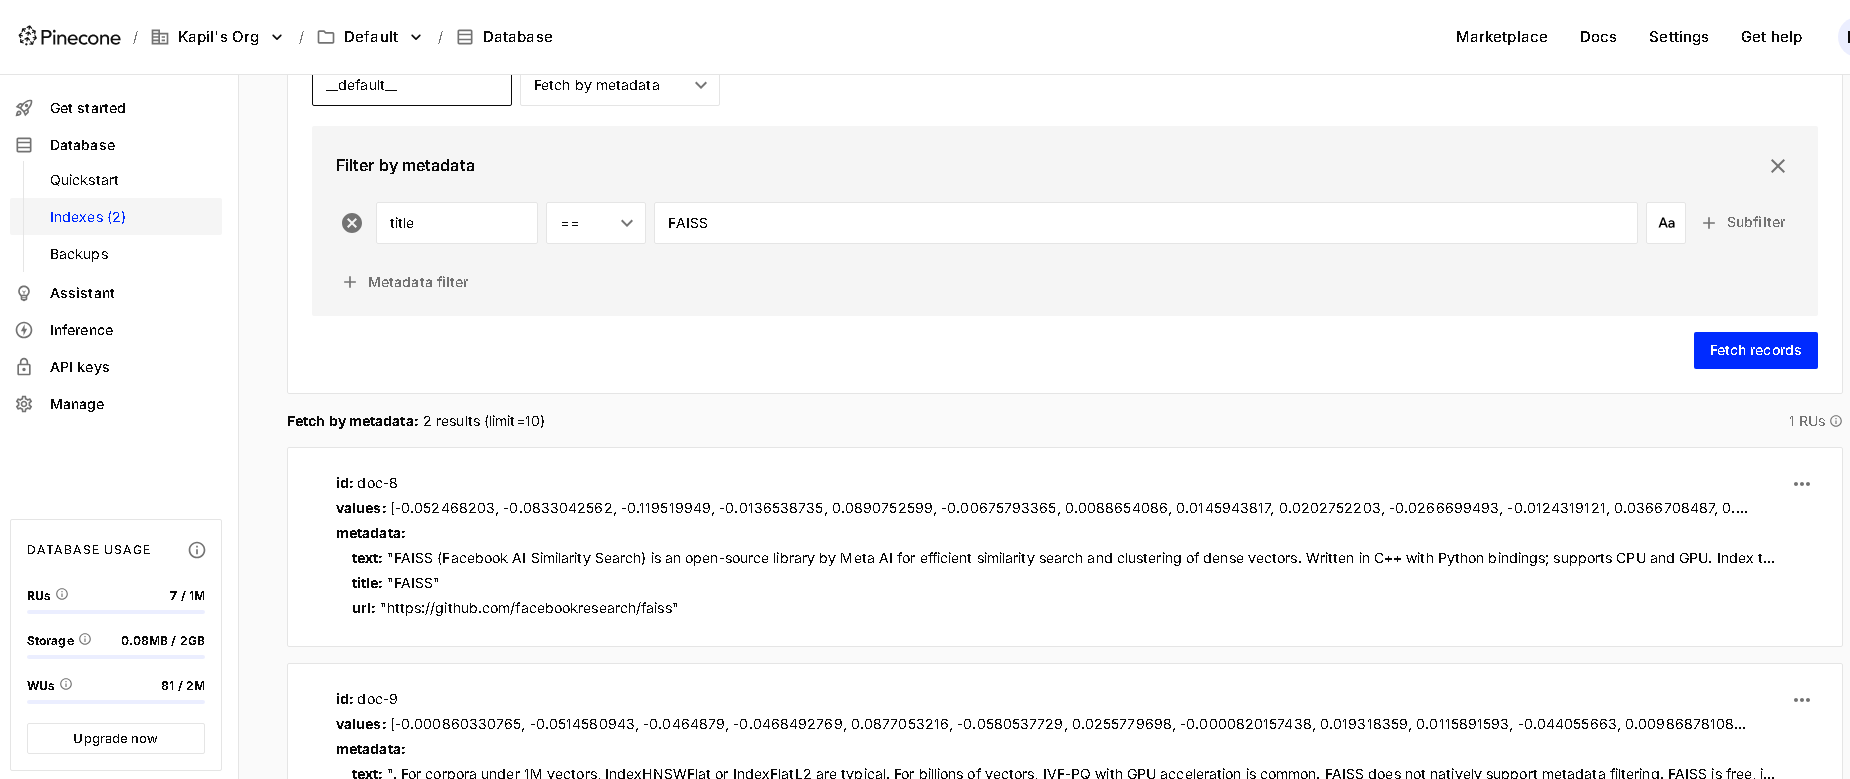